In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pyranges as pr
import os 
import sys
import itertools
sys.path.append('/scratch/eli')
sys.path.append('/data1/normantm/eli/software')
from perturbseq import *
from sparsepca import *
import multiome as mo
from tqdm import tqdm
tqdm.pandas()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [2]:
adata = sc.read('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex_raw.h5ad')
tss = pd.read_csv('/data1/normantm/eli/seq2gex/data/genome/engreitz_tss500.bed', sep='\t', comment='#')
single_targets = {
    x for x in adata.obs['guide_target'].unique()
    if '_' not in x
}

regions = (
    tss
    .query('name in @adata.var_names and name not in @single_targets')
    .loc[:, ['chr', 'start', 'end', 'name', 'strand', 'Ensembl_ID', 'gene_type']]
    .drop_duplicates('name')
    .copy()
)
regions = regions[
    regions['chr'].astype(str).str.startswith('chr') &
    ~regions['chr'].astype(str).str.contains('_') &
    (regions['chr'] != 'chrY')
].copy()

target_genes = regions['name'].tolist()
adata = adata[:, target_genes].copy()

display(pd.Series({
    'cells': adata.n_obs,
    'target_genes': adata.n_vars,
    'guide_targets': adata.obs['guide_target'].nunique(),
    'chromosomes': regions['chr'].nunique(),
}).to_frame('value'))
display(regions['chr'].value_counts().sort_index().to_frame('n_genes').T)

,value
cells,316630
target_genes,8214
guide_targets,1276
chromosomes,23


chr,chr1,chr10,chr11,chr12,chr13,chr14,chr15,chr16,chr17,chr18,...,chr21,chr22,chr3,chr4,chr5,chr6,chr7,chr8,chr9,chrX
n_genes,826,358,472,459,155,285,271,326,465,129,...,82,190,510,334,399,420,389,286,324,263


In [3]:
dg50_pseudo = sc.get.aggregate(adata, by = 'guide_target', func = 'mean')
meanpop = pd.DataFrame(dg50_pseudo.layers['mean'], index = dg50_pseudo.obs_names, columns = dg50_pseudo.var_names)
singles, doubles = meanpop.query("not index.str.contains('_')"), meanpop.query("index.str.contains('_')")
additive = pd.DataFrame(index = doubles.index, columns = doubles.columns)
for tgt in doubles.index:
    a, b = tgt.split('_')
    additive.loc[tgt] = singles.loc[a] + singles.loc[b]

df_add = additive.reset_index().melt(id_vars = 'index', var_name = 'gene', value_name = 'additive')

In [6]:
df = doubles.reset_index().melt(id_vars = 'index', var_name = 'gene', value_name = 'z_ab')
df['z_a'] = df.progress_apply(lambda df: singles.loc[df['index'].split("_")[0], df['gene']], axis=1)
df['z_b'] = df.progress_apply(lambda df: singles.loc[df['index'].split("_")[1], df['gene']], axis=1)
df['z_a^2'] = df['z_a'] ** 2
df['z_b^2'] = df['z_b'] ** 2

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[['z_a', 'z_b', 'z_a^2', 'z_b^2']], df['z_ab'])
model.score(df[['z_a', 'z_b', 'z_a^2', 'z_b^2']], df['z_ab'])

100%|██████████| 10062150/10062150 [02:20<00:00, 71833.59it/s]


0.3478229207565381

In [7]:
model.coef_, model.intercept_

(array([0.555054  , 0.55860763, 0.09244418, 0.11250972]),
 np.float64(0.0009592328793756703))

In [13]:
(additive.columns == doubles.columns).all()

np.True_

In [14]:
c_a, c_b, c_a2, c_b2 = model.coef_
intercept = model.intercept_
ncells = adata.obs.guide_target.value_counts().to_frame('ncells')
vars = adata.to_df()[additive.columns].join(adata.obs.guide_target).groupby('guide_target').var()

resid = pd.DataFrame(index=doubles.index, columns=doubles.columns)
for tgt in doubles.index:
    
    a, b = tgt.split('_')
    
    z_a = singles.loc[a]
    z_b = singles.loc[b]
    
    var_a_eff = vars.loc[a] / ncells.loc[a].item()
    var_b_eff = vars.loc[b] / ncells.loc[b].item()
    
    d_exp_da = c_a + 2 * c_a2 * z_a
    d_exp_db = c_b + 2 * c_b2 * z_b
    
    # adjust singles variance given that we've transformed singles expression via the model, https://en.wikipedia.org/wiki/Delta_method
    # var(f(a, b)) = (df/da)^2 * var(a) + (df/db)^2 * var(b)
    # before with the purely additive model it was just var(a) + var(b) since the gradient terms are each 1

    var_delta = (d_exp_da ** 2) * var_a_eff + (d_exp_db ** 2) * var_b_eff 
    se = np.sqrt(vars.loc[tgt] / ncells.loc[tgt].item() + var_delta)
    
    X_tgt = np.column_stack([z_a, z_b, z_a ** 2, z_b ** 2])
    exp_ab = model.predict(X_tgt)

    resid.loc[tgt] = (doubles.loc[tgt] - exp_ab) / se

resid = resid.astype(np.float32)

df_add['ct_resid'] = resid.reset_index().melt(id_vars = 'index', var_name = 'gene', value_name = 'resid')['resid']

/tmp/ipykernel_622990/2904298072.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/sklearn/util

(-3.5, 3.5)

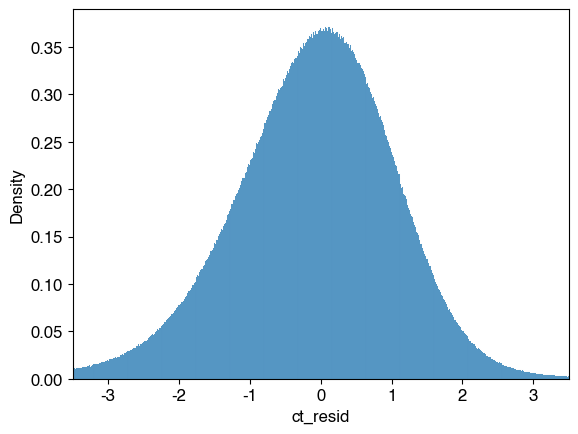

In [19]:
sns.histplot(df_add.ct_resid, stat="density")
plt.xlim(-3.5, 3.5)

(np.float64(-4.4), np.float64(4.4), np.float64(-4.4), np.float64(4.4))

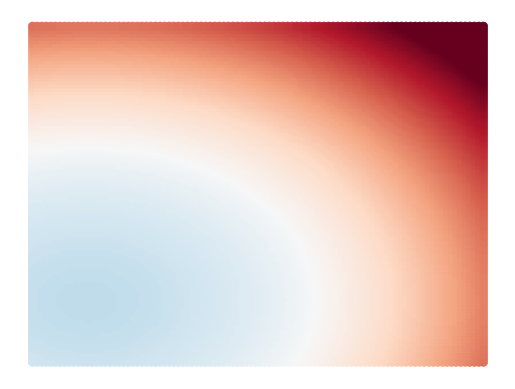

In [20]:
### model expectation

import matplotlib as mpl

grid = np.linspace(-4, 4, 100)
z_a, z_b = np.meshgrid(grid, grid)
df_grid = pd.DataFrame({
    "z_a": z_a.ravel(),
    "z_b": z_b.ravel()
})
df_grid['z_a^2'] = df_grid['z_a'] ** 2
df_grid['z_b^2'] = df_grid['z_b'] ** 2
df_grid['yhat'] = model.predict(df_grid)
sns.scatterplot(df_grid, x = 'z_a', y = 'z_b', hue = 'yhat', palette = 'RdBu_r', edgecolor = None, hue_norm=mpl.colors.Normalize(vmin=-6, vmax=6), legend = None)
plt.axis('off')

(np.float64(-4.4), np.float64(4.4), np.float64(-4.4), np.float64(4.4))

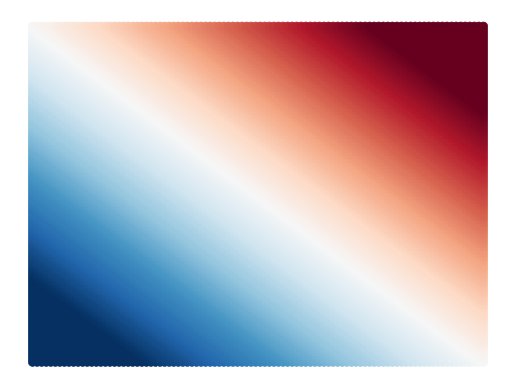

In [21]:
### additive expectation

grid = np.linspace(-4, 4, 100)
z_a, z_b = np.meshgrid(grid, grid)
df_additive = pd.DataFrame({
    "z_a": z_a.ravel(),
    "z_b": z_b.ravel()
})
df_additive['yhat'] = df_additive.z_a + df_additive.z_b
sns.scatterplot(df_additive, x = 'z_a', y = 'z_b', hue = 'yhat', palette = 'RdBu_r', edgecolor = None, legend = None, hue_norm=mpl.colors.Normalize(vmin=-6, vmax=6))
plt.axis('off')

(np.float64(-4.4), np.float64(4.4), np.float64(-4.4), np.float64(4.4))

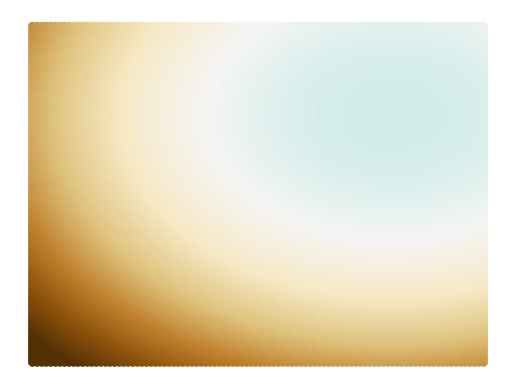

In [ ]:
### difference from additive
# when both singles are very negative, expectation is much higher than additive (this seems correct, absolute expression is bounded at zero so even if you have z_a = -4 and z_b = -4 you will never have z_ab = -8)
# when both singles are very positive, expectation is slightly lower than additive (shrinks outliers but low touch - empirically this seems right also, since for z_a + z_b >> 0 the correlation of z_a + z_b with original t-residual is about 0)
# when at least one single is near zero, the expectation is about additive (zero difference from additive, shown in white)

df_grid['additive_yhat'] = df_additive.yhat
df_grid['diff'] = df_grid.yhat - df_grid.additive_yhat
sns.scatterplot(df_grid, x = 'z_a', y = 'z_b', hue = 'diff', palette = 'BrBG_r', edgecolor = None, legend = None, hue_norm = mpl.colors.Normalize(vmin=-6, vmax=6))
plt.axis('off')

0.04832626290349226


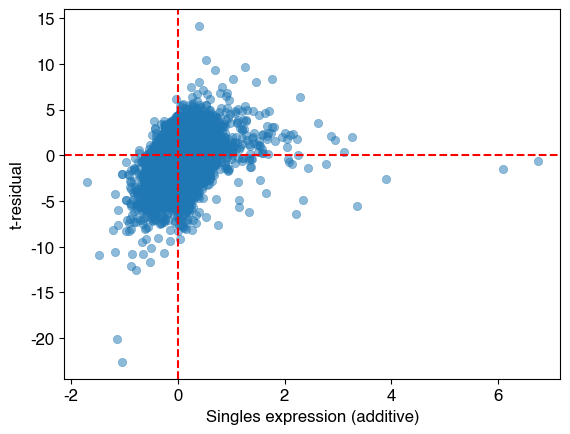

In [23]:
sns.scatterplot(df_add.sample(frac = 0.01, random_state=42), x = 'additive', y = 'ct_resid', edgecolor = None, alpha = 0.5)
plt.xlabel("Singles expression (additive)")
plt.ylabel("t-residual")
print(df_add[['additive', 'ct_resid']].corr().iloc[0,1])
plt.axhline(0, color = 'red', linestyle = '--')
plt.axvline(0, color = 'red', linestyle = '--')

In [ ]:
resid.to_parquet("intermediate_files/t_residuals.parquet")